<a href="https://colab.research.google.com/github/AnnaZapototska/colab-code-work/blob/development/hw_task4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 4

Approaches to quality improvement

In [42]:
!pip install category_encoders

## Part 1

In [73]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pickle

from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor


In [44]:
!wget -O mod_05_topic_10_various_data.pkl \
https://raw.githubusercontent.com/goitacademy/MACHINE-LEARNING-NEO/main/datasets/mod_05_topic_10_various_data.pkl


--2026-08-29 19:08:23--  https://raw.githubusercontent.com/goitacademy/MACHINE-LEARNING-NEO/main/datasets/mod_05_topic_10_various_data.pkl
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 18343147 (17M) [application/octet-stream]
Saving to: ‘mod_05_topic_10_various_data.pkl’

mod_05_topic_10_var 100%[===================>]  17.49M  --.-KB/s    in 0.1s    

2026-08-29 19:08:23 (175 MB/s) - ‘mod_05_topic_10_various_data.pkl’ saved [18343147/18343147]



In [45]:
with open('mod_05_topic_10_various_data.pkl', 'rb') as fl:
    datasets = pickle.load(fl)

## Part 2

In [46]:
autos = datasets['autos']

autos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   make               193 non-null    object 
 1   fuel_type          193 non-null    object 
 2   aspiration         193 non-null    object 
 3   num_of_doors       193 non-null    int64  
 4   body_style         193 non-null    object 
 5   drive_wheels       193 non-null    object 
 6   engine_location    193 non-null    object 
 7   wheel_base         193 non-null    float64
 8   length             193 non-null    float64
 9   width              193 non-null    float64
 10  height             193 non-null    float64
 11  curb_weight        193 non-null    int64  
 12  engine_type        193 non-null    object 
 13  num_of_cylinders   193 non-null    int64  
 14  engine_size        193 non-null    int64  
 15  fuel_system        193 non-null    object 
 16  bore               193 non

In [47]:
autos.nunique().sort_values()

,0
fuel_type,2
aspiration,2
num_of_doors,2
engine_location,2
drive_wheels,3
body_style,5
engine_type,5
num_of_cylinders,6
fuel_system,7
compression_ratio,8


Discrete meaning:
make,
fuel_type,
aspiration,
num_of_doors,
body_style,
drive_wheels,
engine_location,
engine_type,
num_of_cylinders,
fuel_system

In [48]:
discrete_features = [
    'make',
    'fuel_type',
    'aspiration',
    'num_of_doors',
    'body_style',
    'drive_wheels',
    'engine_location',
    'engine_type',
    'num_of_cylinders',
    'fuel_system'
]

## Part 3

In [49]:
X = autos.drop(columns='price').copy()
y = autos['price']

In [50]:
cat_features = X.select_dtypes('object').columns

In [51]:
for col in cat_features:
    X[col], _ = X[col].factorize()

In [52]:
categorical_features = [
    'make',
    'fuel_type',
    'aspiration',
    'body_style',
    'drive_wheels',
    'engine_location',
    'engine_type',
    'fuel_system'
]

In [53]:
discrete_mask = X.columns.isin(discrete_features)

In [54]:
mi = mutual_info_regression(
    X,
    y,
    discrete_features=discrete_mask,
    random_state=42
)

In [55]:
mi_df = pd.DataFrame({
    'feature': X.columns,
    'mutual_information': mi
})

mi_df = mi_df.sort_values(
    'mutual_information',
    ascending=False
)

mi_df

,feature,mutual_information
11,curb_weight,0.911713
14,engine_size,0.900925
19,horsepower,0.891165
22,highway_mpg,0.887362
21,city_mpg,0.774127
9,width,0.679991
8,length,0.612483
7,wheel_base,0.588635
0,make,0.543268
16,bore,0.497420


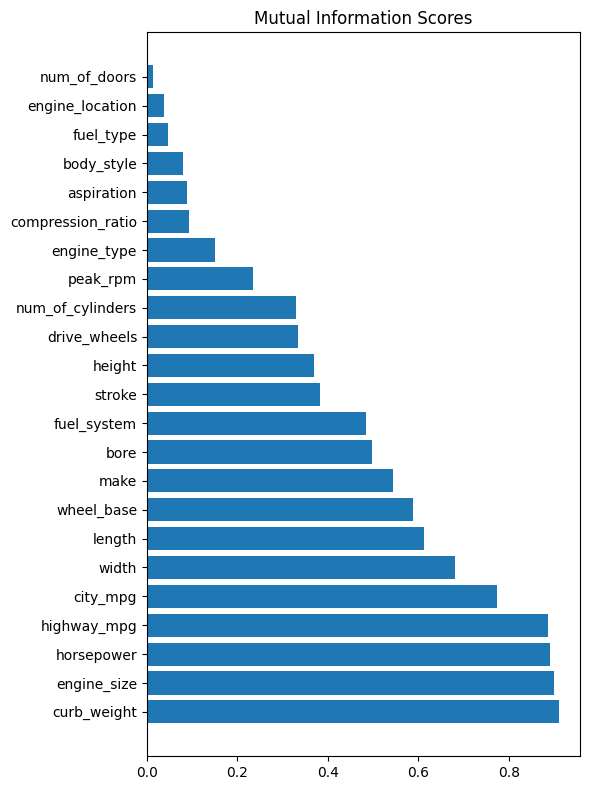

In [56]:
plt.figure(figsize=(6, 8))
plt.barh(
    np.arange(len(mi_df)),
    mi_df['mutual_information']
)
plt.yticks(
    np.arange(len(mi_df)),
    mi_df['feature']
)
plt.title('Mutual Information Scores')
plt.tight_layout()
plt.show()

## Part 4

In [57]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X, y)

importance_df = pd.DataFrame({
    'feature': X.columns,
    'feature_importance': model.feature_importances_
}).sort_values('feature_importance', ascending=False)

importance_df

,feature,feature_importance
14,engine_size,0.652357
11,curb_weight,0.213646
22,highway_mpg,0.031783
19,horsepower,0.018450
0,make,0.015087
9,width,0.014332
8,length,0.008704
7,wheel_base,0.006101
17,stroke,0.005409
20,peak_rpm,0.005203


## Part 5

In [58]:
comparison_df = mi_df.merge(
    importance_df,
    on='feature'
)

In [59]:
comparison_df.head()

,feature,mutual_information,feature_importance
0,curb_weight,0.911713,0.213646
1,engine_size,0.900925,0.652357
2,horsepower,0.891165,0.018450
3,highway_mpg,0.887362,0.031783
4,city_mpg,0.774127,0.004363


In [60]:
comparison_df['mutual_information'] = (
    comparison_df['mutual_information'].rank(pct=True)
)

comparison_df['feature_importance'] = (
    comparison_df['feature_importance'].rank(pct=True)
)
comparison_df

,feature,mutual_information,feature_importance
0,curb_weight,1.000000,0.956522
1,engine_size,0.956522,1.000000
2,horsepower,0.913043,0.869565
3,highway_mpg,0.869565,0.913043
4,city_mpg,0.826087,0.521739
5,width,0.782609,0.782609
6,length,0.739130,0.739130
7,wheel_base,0.695652,0.695652
8,make,0.652174,0.826087
9,bore,0.608696,0.478261


## Part 6

In [68]:
comparison_df = comparison_df.sort_values(
    'mutual_information',
    ascending=True
)

In [69]:
plot_df = comparison_df.melt(
    id_vars='feature',
    value_vars=['mutual_information', 'feature_importance'],
    var_name='metric',
    value_name='rank'
)

In [70]:
plot_df.head()

,feature,metric,rank
0,num_of_doors,mutual_information,0.043478
1,engine_location,mutual_information,0.086957
2,fuel_type,mutual_information,0.130435
3,body_style,mutual_information,0.173913
4,aspiration,mutual_information,0.217391


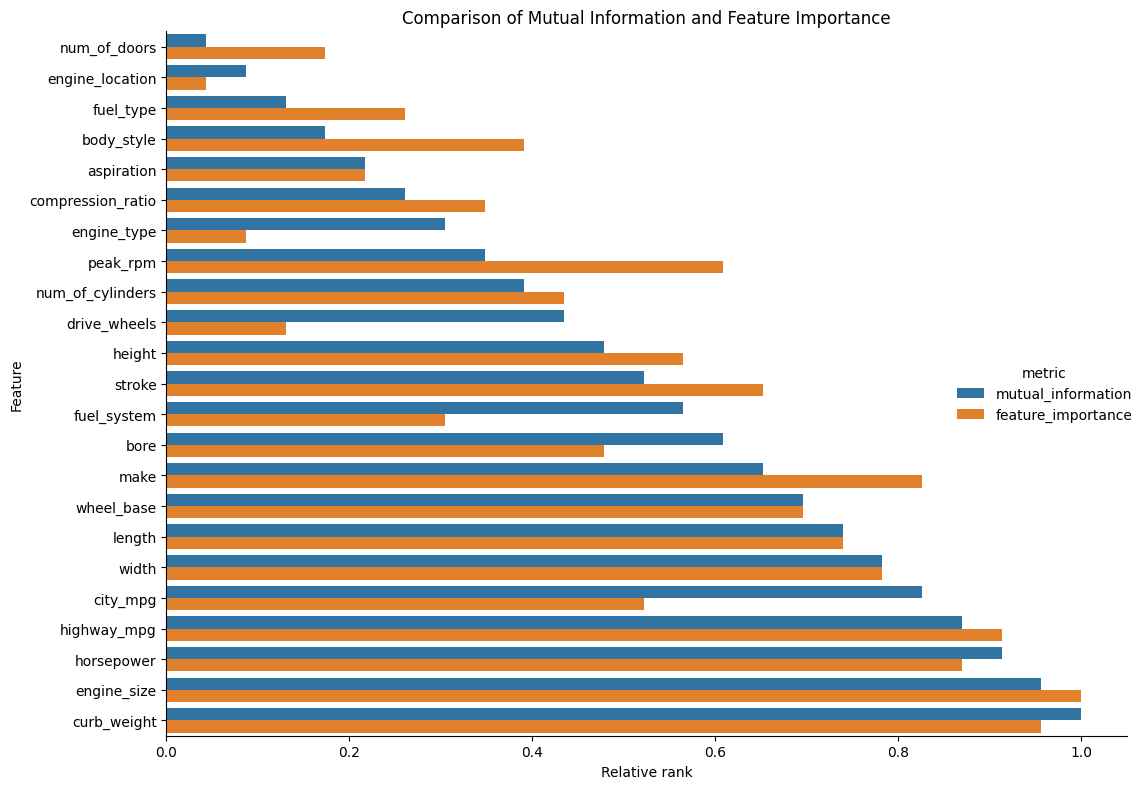

In [72]:
sns.catplot(
    data=plot_df,
    y='feature',
    x='rank',
    hue='metric',
    kind='bar',
    height=8,
    aspect=1.2
)

plt.xlabel('Relative rank')
plt.ylabel('Feature')
plt.title('Comparison of Mutual Information and Feature Importance')

plt.tight_layout()
plt.show()

## Part with GradientBoostingRegressor

In [76]:
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    random_state=42
)

gb_model.fit(X, y)

GradientBoostingRegressor(random_state=42)

In [79]:
gb_importance_df = pd.DataFrame({
    'feature': X.columns,
    'feature_importance': gb_model.feature_importances_
}).sort_values(
    'feature_importance',
    ascending=False
)

gb_importance_df

,feature,feature_importance
14,engine_size,0.629277
11,curb_weight,0.172734
19,horsepower,0.058336
22,highway_mpg,0.030027
9,width,0.016727
0,make,0.015686
7,wheel_base,0.013254
8,length,0.012475
13,num_of_cylinders,0.010778
21,city_mpg,0.007257


In [81]:
gb_comparison_df = mi_df.merge(
    gb_importance_df,
    on='feature'
)

In [82]:
gb_comparison_df['mutual_information'] = (
    gb_comparison_df['mutual_information'].rank(pct=True)
)

gb_comparison_df['feature_importance'] = (
    gb_comparison_df['feature_importance'].rank(pct=True)
)

In [83]:
gb_plot_df = gb_comparison_df.melt(
    id_vars='feature',
    value_vars=['mutual_information', 'feature_importance'],
    var_name='metric',
    value_name='rank'
)

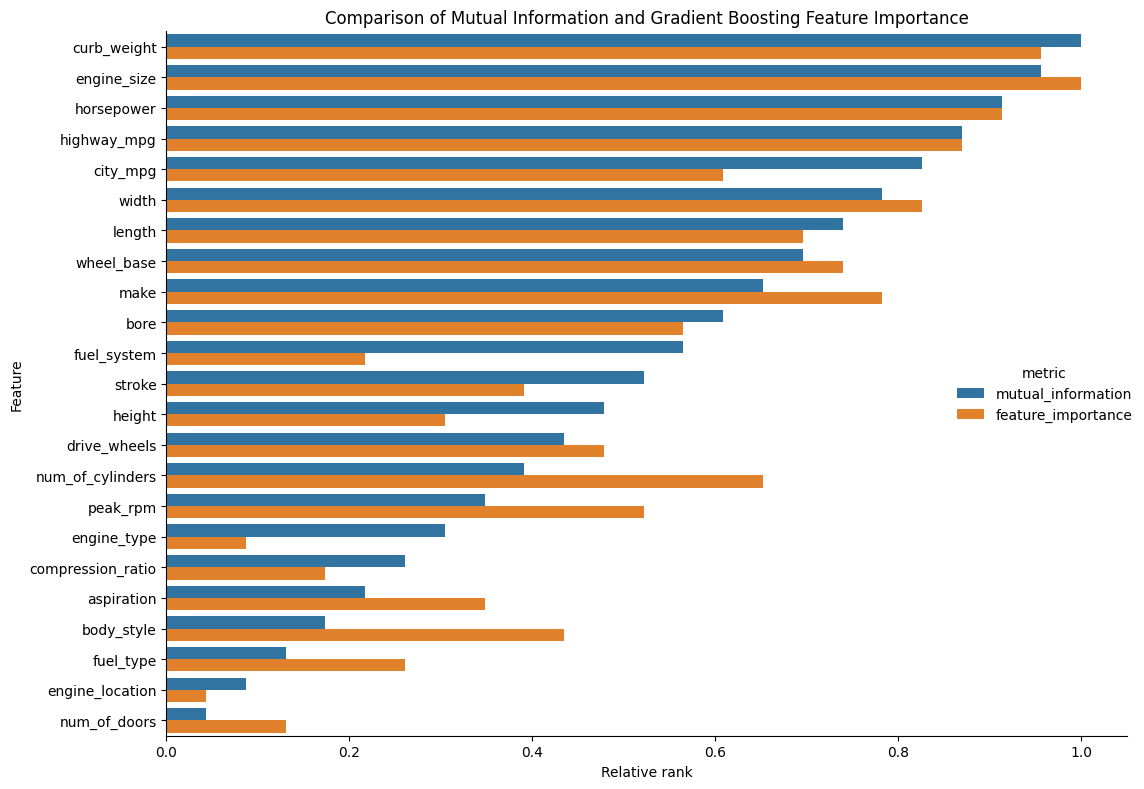

In [85]:
sns.catplot(
    data=gb_plot_df,
    y='feature',
    x='rank',
    hue='metric',
    kind='bar',
    height=8,
    aspect=1.2
)

plt.xlabel('Relative rank')
plt.ylabel('Feature')
plt.title('Comparison of Mutual Information and Gradient Boosting Feature Importance')

plt.tight_layout()
plt.show()

## Part 7: Summary

A comparison of relative ranks showed that the estimates of mutual information and feature importance in the models generally have a similar trend, especially for the most significant features (curb_weight, engine_size, horsepower, highway_mpg). At the same time, for a number of features, the ranks differ significantly. This is explained by the fact that mutual information estimates the statistical relationship of a single feature with the target variable, while feature importance estimates the contribution of a feature to building a specific model, taking into account other features and their interactions. Therefore, MI can be useful for initial feature selection, but the final utility of features should also be assessed in the context of a specific model.



The difference between your two graphs can be described as follows:

Random Forest: The differences between MI and importance are more noticeable for some features, such as peak_rpm, make, fuel_system.

Gradient Boosting: The results generally seem more consistent with MI for the top of the rankings — curb_weight, engine_size, horsepower, highway_mpg, city_mpg, width.

In both cases, curb_weight and engine_size are consistently among the most important features, which is the most obvious common result.